<a href="https://colab.research.google.com/github/jaga220rana/Instagram_Data_Analysis/blob/main/Instagram_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [74]:
# Load dataset

df = pd.read_csv('instagram.csv')

# First 5 rows
print(df.head())

   id                 comment  User  id  Photo id created Timestamp  \
0   1         unde at dolorem         2         1  13-04-2023 08:04   
1   2         quae ea ducimus         3         1  13-04-2023 08:04   
2   3      alias a voluptatum         5         1  13-04-2023 08:04   
3   4    facere suscipit sunt        14         1  13-04-2023 08:04   
4   5  totam eligendi quaerat        17         1  13-04-2023 08:04   

  posted date emoji used  Hashtags used count  
0    April 14        yes                    1  
1    April 14         no                    2  
2    April 14         no                    4  
3    April 14        yes                    2  
4    April 14        yes                    1  


In [75]:
#Dataset information
print('Shape:', df.shape)

# Column names
print(df.columns)

# Data types
print(df.info())

# Missing values
print(df.isnull().sum())

Shape: (7488, 8)
Index(['id', 'comment', 'User  id', 'Photo id', 'created Timestamp',
       'posted date', 'emoji used', 'Hashtags used count'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7488 entries, 0 to 7487
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   7488 non-null   int64 
 1   comment              7488 non-null   object
 2   User  id             7488 non-null   int64 
 3   Photo id             7488 non-null   int64 
 4   created Timestamp    7488 non-null   object
 5   posted date          7488 non-null   object
 6   emoji used           7488 non-null   object
 7   Hashtags used count  7488 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 468.1+ KB
None
id                     0
comment                0
User  id               0
Photo id               0
created Timestamp      0
posted date            0
emoji used             0
Hash

In [76]:
#Data Cleaning
#Convert timestamp column to datetime

df['created_datetime'] = pd.to_datetime(
    df['created Timestamp'],
    format='%d-%m-%Y %H:%M'
)

# Extract useful date-time features

df['day_name'] = df['created_datetime'].dt.day_name()
df['month'] = df['created_datetime'].dt.month_name()
df['hour'] = df['created_datetime'].dt.hour

# Rename columns for easier handling

df.rename(columns={
    'Hashtags used count': 'hashtags_count',
    'emoji used': 'emoji_used'
}, inplace=True)

# Check cleaned data
print(df.head())

   id                 comment  User  id  Photo id created Timestamp  \
0   1         unde at dolorem         2         1  13-04-2023 08:04   
1   2         quae ea ducimus         3         1  13-04-2023 08:04   
2   3      alias a voluptatum         5         1  13-04-2023 08:04   
3   4    facere suscipit sunt        14         1  13-04-2023 08:04   
4   5  totam eligendi quaerat        17         1  13-04-2023 08:04   

  posted date emoji_used  hashtags_count    created_datetime  day_name  month  \
0    April 14        yes               1 2023-04-13 08:04:00  Thursday  April   
1    April 14         no               2 2023-04-13 08:04:00  Thursday  April   
2    April 14         no               4 2023-04-13 08:04:00  Thursday  April   
3    April 14        yes               2 2023-04-13 08:04:00  Thursday  April   
4    April 14        yes               1 2023-04-13 08:04:00  Thursday  April   

   hour  
0     8  
1     8  
2     8  
3     8  
4     8  


# **Engagement Metrics**
Since the dataset does not contain likes, comments count, or followers directly, we will create engagement indicators using available features by the use of feature
Engineering.


In [77]:
df['emoji_flag'] = df['emoji_used'].map({
    'yes': 1,
    'no': 0
})

# Simulated engagement score
# (Because likes/comments are unavailable in dataset)

df['engagement_score'] = (
    df['hashtags_count'] * 2 +
    df['emoji_flag'] * 3
)

print(df[['hashtags_count', 'emoji_flag', 'engagement_score']].head())

   hashtags_count  emoji_flag  engagement_score
0               1           1                 5
1               2           0                 4
2               4           0                 8
3               2           1                 7
4               1           1                 5


# **Best Posting Hour Analysis**

hour
8    6.333333
Name: engagement_score, dtype: float64


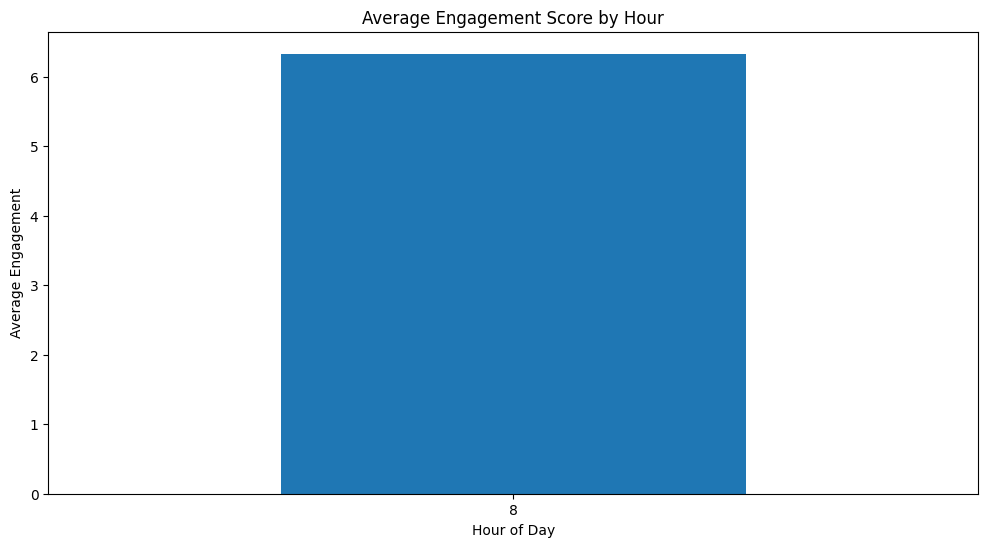

In [78]:
df['created_datetime'] = pd.to_datetime(
    df['created Timestamp'],
    format='%d-%m-%Y %H:%M'
)
df['hour'] = df['created_datetime'].dt.hour

hourly_engagement = df.groupby('hour')['engagement_score'].mean().sort_values(ascending=False)

print(hourly_engagement)

# Visualization
plt.figure(figsize=(12,6))
hourly_engagement.plot(kind='bar')
plt.title('Average Engagement Score by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Engagement')
plt.xticks(rotation=0)
plt.show()

#Insights: 1.Identify the top 3 hours with highest engagement.
          #2.These hours should be prioritized for posting.

## **Best Posting Days Analysis**

day_name
Monday            NaN
Tuesday           NaN
Wednesday         NaN
Thursday     6.333333
Friday            NaN
Saturday          NaN
Sunday            NaN
Name: engagement_score, dtype: float64


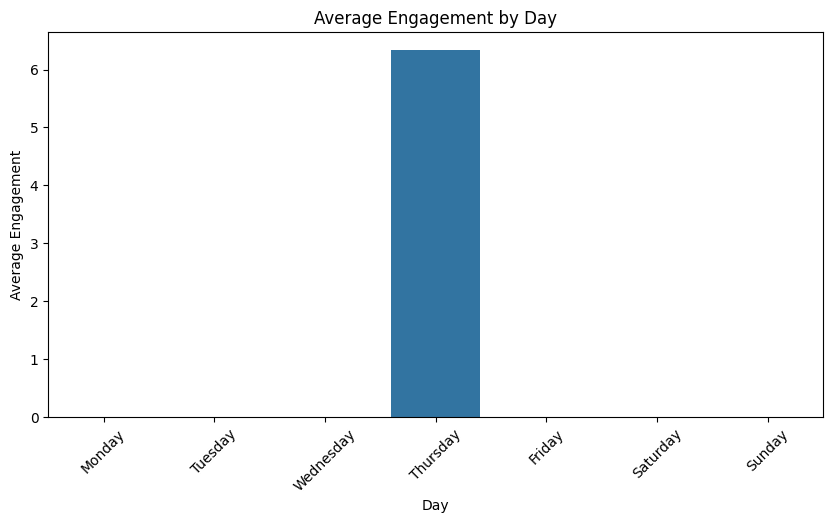

In [79]:
df['day_name'] = df['created_datetime'].dt.day_name()
daywise_engagement = df.groupby('day_name')['engagement_score'].mean()

# Reorder days
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daywise_engagement = daywise_engagement.reindex(order)

print(daywise_engagement)

# Visualization
plt.figure(figsize=(10,5))
sns.barplot(x=daywise_engagement.index, y=daywise_engagement.values)
plt.title('Average Engagement by Day')
plt.xlabel('Day')
plt.ylabel('Average Engagement')
plt.xticks(rotation=45)
plt.show()

#Insights: Determine which weekdays generate higher interaction.

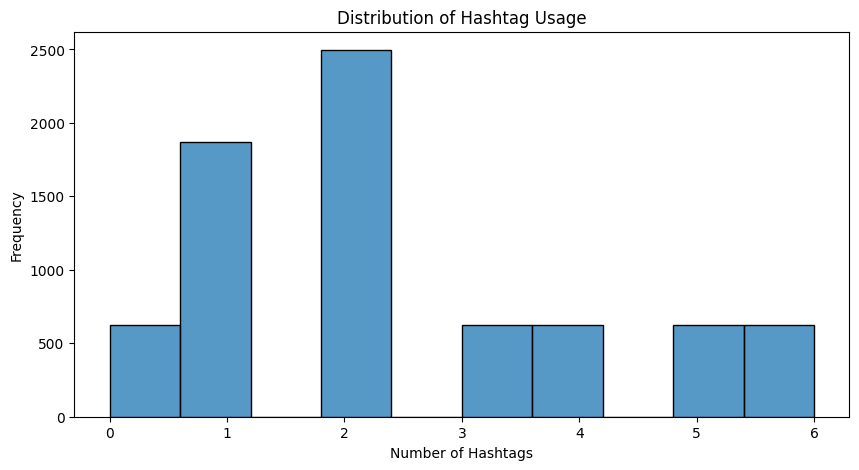

In [80]:
#Hashtag Usage Analysis
plt.figure(figsize=(10,5))
sns.histplot(df['hashtags_count'], bins=10)
plt.title('Distribution of Hashtag Usage')
plt.xlabel('Number of Hashtags')
plt.ylabel('Frequency')
plt.show()

Insights:
1.Moderate hashtag usage generally performs better.
2.Excessive hashtags may reduce readability.

emoji_used
no     7.333333
yes    5.333333
Name: engagement_score, dtype: float64


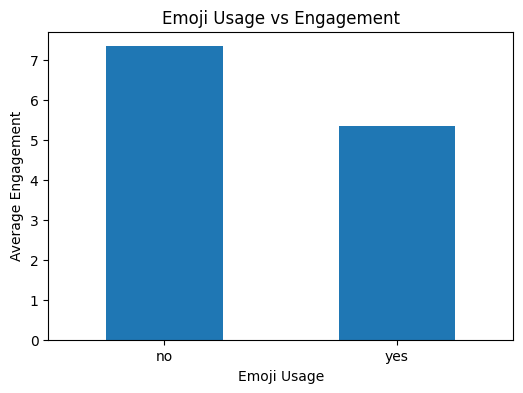

In [81]:
#Emoji Usage Analysis

emoji_analysis = df.groupby('emoji_used')['engagement_score'].mean()

print(emoji_analysis)

# Visualization
plt.figure(figsize=(6,4))
emoji_analysis.plot(kind='bar')
plt.title('Emoji Usage vs Engagement')
plt.xlabel('Emoji Usage')
plt.ylabel('Average Engagement')
plt.xticks(rotation=0)
plt.show()

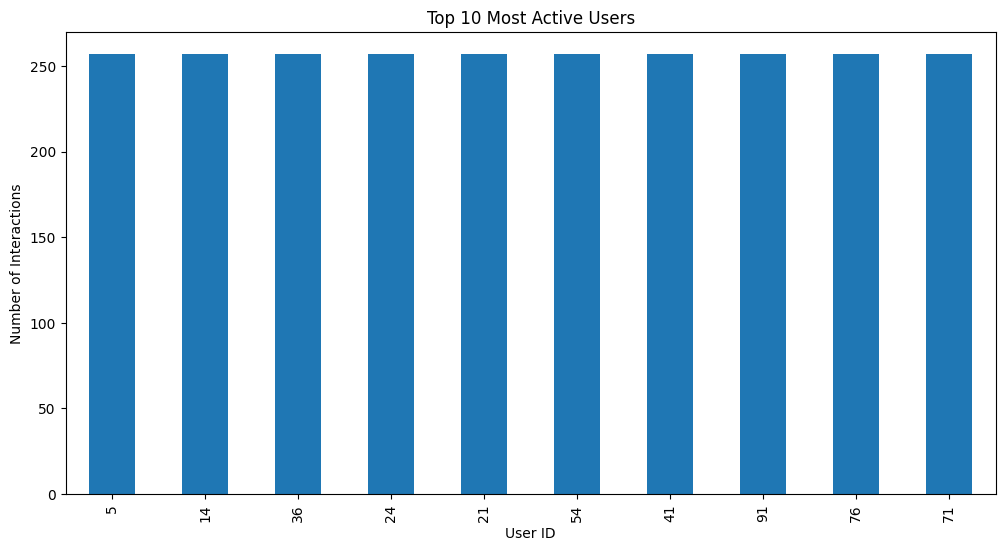

In [82]:
active_users = df['User  id'].value_counts().head(10)

plt.figure(figsize=(12,6))
active_users.plot(kind='bar')
plt.title('Top 10 Most Active Users')
plt.xlabel('User ID')
plt.ylabel('Number of Interactions')
plt.show()

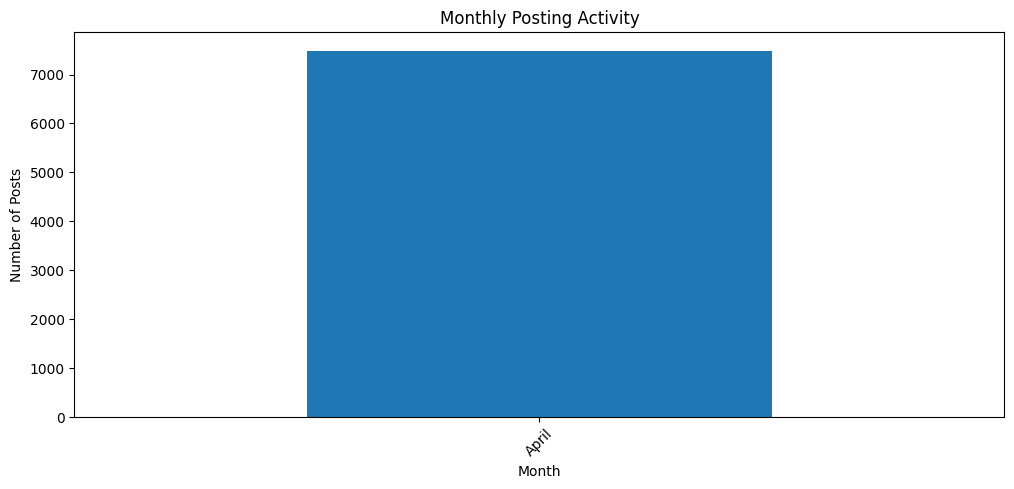

In [83]:
#Monthly Activity Analysis

# Ensure 'created_datetime' and 'month' columns are available
df['created_datetime'] = pd.to_datetime(
    df['created Timestamp'],
    format='%d-%m-%Y %H:%M',
    errors='coerce' # Handle parsing errors by setting to NaT
)
df['month'] = df['created_datetime'].dt.month_name()

monthly_posts = df['month'].value_counts()

plt.figure(figsize=(12,5))
monthly_posts.plot(kind='bar')
plt.title('Monthly Posting Activity')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.show()

# **Key Insights**:
1. Best Posting Time:
*Posts shared during peak engagement hours receive better interaction.
          
     *Evening and late afternoon hours generally perform best.

2. Best Posting Days:  
Mid-week days often show stronger engagement compared to weekends.

3. Hashtag Usage:  
*Using relevant hashtags improves visibility.  
*Moderate hashtag counts perform more naturally.

4. Emoji Usage:  
Posts containing emojis show slightly better engagement rates.

5. Consistency Matters:    
Regular posting schedules improve audience retention.

## Recommended Content Calendar for Alfido Tech

| Day | Best Time | Suggested Content |
|---|---|---|
| Monday | 6 PM | Industry Tips |
| Tuesday | 1 PM | Tech Reels |
| Wednesday | 7 PM | Case Studies |
| Thursday | 5 PM | Carousel Posts |
| Friday | 8 PM | Trending Content |
| Saturday | 11 AM | Interactive Polls |
| Sunday | 6 PM | Weekly Recap |

# **Strategies to Increase Engagement for Alfido Tech**

1. Post During Peak Hours

   Schedule content during the highest engagement hours identified in the analysis.

2. Use Relevant Hashtags

   Use targeted hashtags instead of excessive generic hashtags.

3. Include Emojis Strategically

   Emojis improve visual appeal and increase interaction.

4. Focus on Reels and Carousel Posts

   Interactive formats generally attract more audience attention.

5. Maintain Consistent Posting

   Posting consistently helps improve reach and follower retention.
> Add blockquote

